In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os

from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
df = pd.read_csv('health_index_dataset.csv')

print("Dataset Shape:", df.shape)
print("\nColumns:", list(df.columns))
print("\nFirst 5 rows:")
print(df.head())
print("\nBasic Statistics:")
print(df.describe())

Dataset Shape: (470, 15)

Columns: ['Hydrogen', 'Oxigen', 'Nitrogen', 'Methane', 'CO', 'CO2', 'Ethylene', 'Ethane', 'Acethylene', 'DBDS', 'Power factor', 'Interfacial V', 'Dielectric rigidity', 'Water content', 'Health index']

First 5 rows:
   Hydrogen  Oxigen  Nitrogen  Methane   CO   CO2  Ethylene  Ethane  \
0      2845    5860     27842     7406   32  1344     16684    5467   
1     12886      61     25041      877   83   864         4     305   
2      2820   16400     56300      144  257  1080       206      11   
3      1099      70     37520      545  184  1402         6     230   
4      3210    3570     47900      160  360  2130         4      43   

   Acethylene  DBDS  Power factor  Interfacial V  Dielectric rigidity  \
0           7  19.0          1.00             45                   55   
1           0  45.0          1.00             45                   55   
2        2190   1.0          1.00             39                   52   
3           0  87.0          4.58      


Missing Values:
Hydrogen               0
Oxigen                 0
Nitrogen               0
Methane                0
CO                     0
CO2                    0
Ethylene               0
Ethane                 0
Acethylene             0
DBDS                   0
Power factor           0
Interfacial V          0
Dielectric rigidity    0
Water content          0
Health index           0
dtype: int64

Duplicate rows: 0


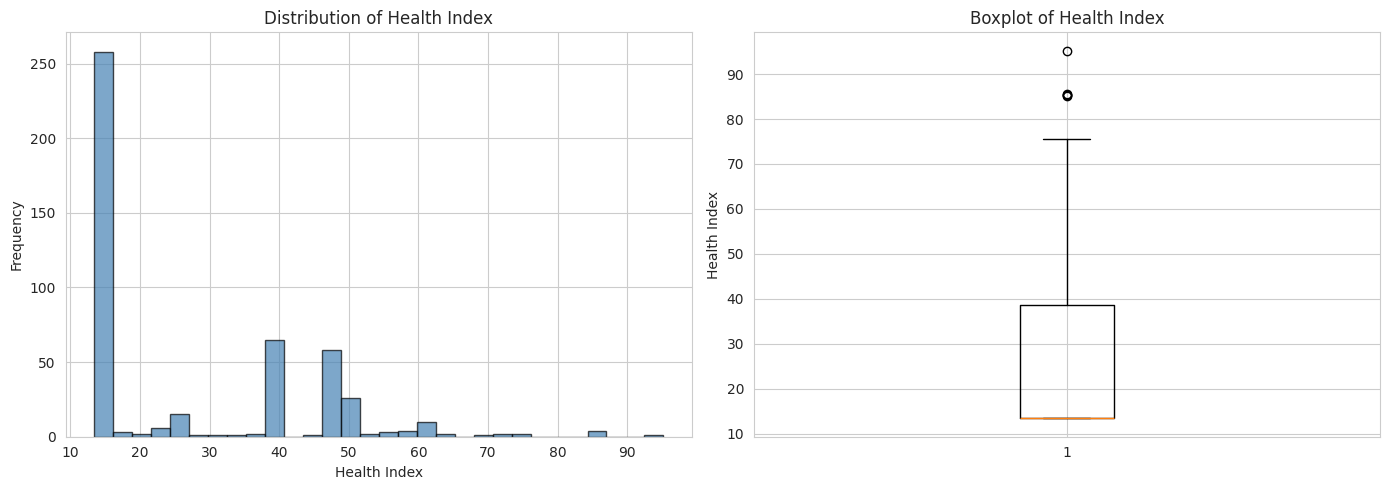


Health Index Statistics:
  Mean:    27.50
  Std Dev: 17.74
  Min:     13.40
  Max:     95.20


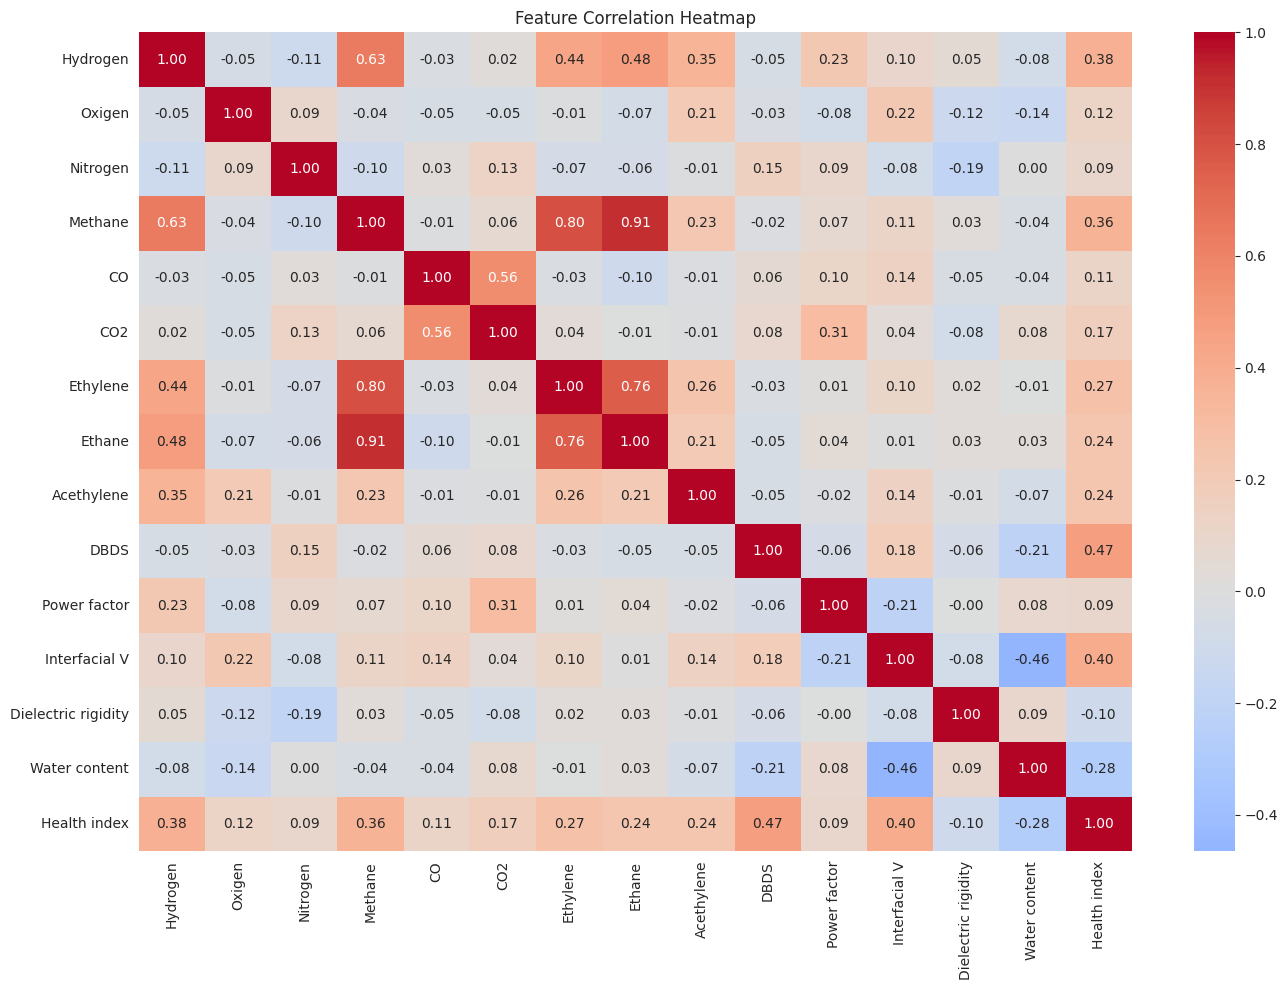


Feature Correlation with Health Index:
Health index           1.000000
DBDS                   0.468809
Interfacial V          0.400216
Hydrogen               0.377388
Methane                0.361770
Ethylene               0.271504
Acethylene             0.240143
Ethane                 0.236507
CO2                    0.168777
Oxigen                 0.121009
CO                     0.112751
Power factor           0.092729
Nitrogen               0.089455
Dielectric rigidity   -0.104426
Water content         -0.281165
Name: Health index, dtype: float64


In [3]:
# Missing values and duplicates
print("\nMissing Values:")
print(df.isnull().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")

# Health Index distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Health index'], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_xlabel('Health Index')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Health Index')

axes[1].boxplot(df['Health index'])
axes[1].set_ylabel('Health Index')
axes[1].set_title('Boxplot of Health Index')

plt.tight_layout()
plt.savefig('health_index_distribution.png', dpi=150)
plt.show()

print(f"\nHealth Index Statistics:")
print(f"  Mean:    {df['Health index'].mean():.2f}")
print(f"  Std Dev: {df['Health index'].std():.2f}")
print(f"  Min:     {df['Health index'].min():.2f}")
print(f"  Max:     {df['Health index'].max():.2f}")

# Correlation heatmap
plt.figure(figsize=(14, 10))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

print("\nFeature Correlation with Health Index:")
print(df.corr()['Health index'].sort_values(ascending=False))

In [4]:
COLUMN_RENAME = {
    'Hydrogen':            'hydrogen',
    'Oxigen':              'oxygen',
    'Nitrogen':            'nitrogen',
    'Methane':             'methane',
    'CO':                  'co',
    'CO2':                 'co2',
    'Ethylene':            'ethylene',
    'Ethane':              'ethane',
    'Acethylene':          'acetylene',
    'DBDS':                'dbds',
    'Power factor':        'power_factor',
    'Interfacial V':       'interfacial_v',
    'Dielectric rigidity': 'dielectric_rigidity',
    'Water content':       'water_content',
    'Health index':        'health_index',
}

df = df.rename(columns=COLUMN_RENAME)
df = df.drop_duplicates()

FEATURE_COLUMNS = [
    'hydrogen', 'oxygen', 'nitrogen', 'methane', 'co', 'co2',
    'ethylene', 'ethane', 'acetylene', 'dbds',
    'power_factor', 'interfacial_v', 'dielectric_rigidity', 'water_content'
]

X = df[FEATURE_COLUMNS]
y = df['health_index']

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape:   {y.shape}")
print(f"Feature names:  {FEATURE_COLUMNS}")


Features shape: (470, 14)
Target shape:   (470,)
Feature names:  ['hydrogen', 'oxygen', 'nitrogen', 'methane', 'co', 'co2', 'ethylene', 'ethane', 'acetylene', 'dbds', 'power_factor', 'interfacial_v', 'dielectric_rigidity', 'water_content']


In [5]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42)

print(f"\nTraining set:   {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Validation set: {X_val.shape[0]} samples ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Test set:       {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")


Training set:   329 samples (70.0%)
Validation set: 70 samples (14.9%)
Test set:       71 samples (15.1%)


In [6]:
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled   = scaler_X.transform(X_val)
X_test_scaled  = scaler_X.transform(X_test)

print("\nFeatures normalized using StandardScaler.")
print(f"X_train scaled shape: {X_train_scaled.shape}")


Features normalized using StandardScaler.
X_train scaled shape: (329, 14)


In [8]:
print("\nModel: RandomForestRegressor")

model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)


Model: RandomForestRegressor


In [9]:
print("\nTraining RandomForestRegressor...")
model.fit(X_train_scaled, y_train)
print("Training complete.")

# Cross-validation on training set
cv_scores = cross_val_score(model, X_train_scaled, y_train,
                             cv=5, scoring='r2')
print(f"\n5-Fold CV R² on training set: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


Training RandomForestRegressor...
Training complete.

5-Fold CV R² on training set: 0.6558 ± 0.0735


In [10]:
y_val_pred = model.predict(X_val_scaled)

val_mae  = mean_absolute_error(y_val, y_val_pred)
val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
val_r2   = r2_score(y_val, y_val_pred)

print("\nValidation Metrics:")
print(f"  MAE:  {val_mae:.4f}")
print(f"  RMSE: {val_rmse:.4f}")
print(f"  R²:   {val_r2:.4f}")


Validation Metrics:
  MAE:  6.4508
  RMSE: 9.9702
  R²:   0.7512


In [11]:
y_test_pred = model.predict(X_test_scaled)

test_mae  = mean_absolute_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_r2   = r2_score(y_test, y_test_pred)

print("\nTest Metrics:")
print(f"  MAE:  {test_mae:.4f}")
print(f"  RMSE: {test_rmse:.4f}")
print(f"  R²:   {test_r2:.4f}")


Test Metrics:
  MAE:  6.4817
  RMSE: 9.7757
  R²:   0.7098


In [12]:
y_train_pred = model.predict(X_train_scaled)

metrics_df = pd.DataFrame({
    'Dataset':  ['Training', 'Validation', 'Test'],
    'Samples':  [len(X_train), len(X_val), len(X_test)],
    'MAE':      [mean_absolute_error(y_train, y_train_pred), val_mae, test_mae],
    'RMSE':     [np.sqrt(mean_squared_error(y_train, y_train_pred)), val_rmse, test_rmse],
    'R²':       [r2_score(y_train, y_train_pred), val_r2, test_r2],
})

In [13]:
print("\nComprehensive Metrics:")
print(metrics_df.to_string(index=False))


Comprehensive Metrics:
   Dataset  Samples      MAE     RMSE       R²
  Training      329 2.351117 3.710875 0.952014
Validation       70 6.450814 9.970195 0.751184
      Test       71 6.481746 9.775679 0.709752


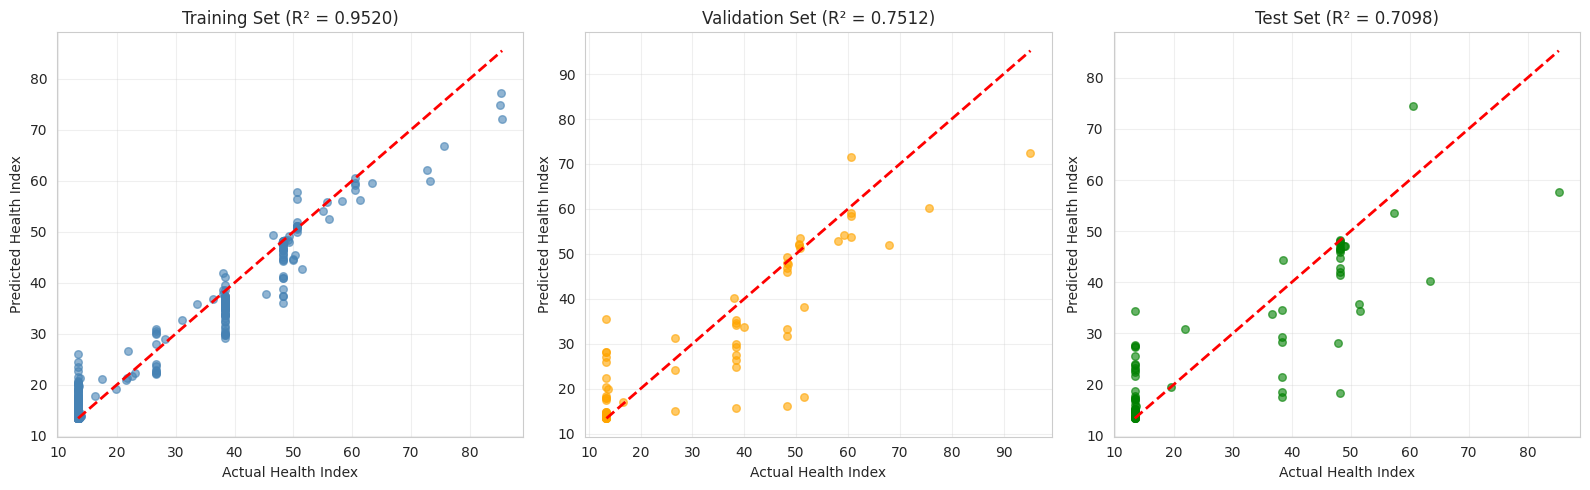

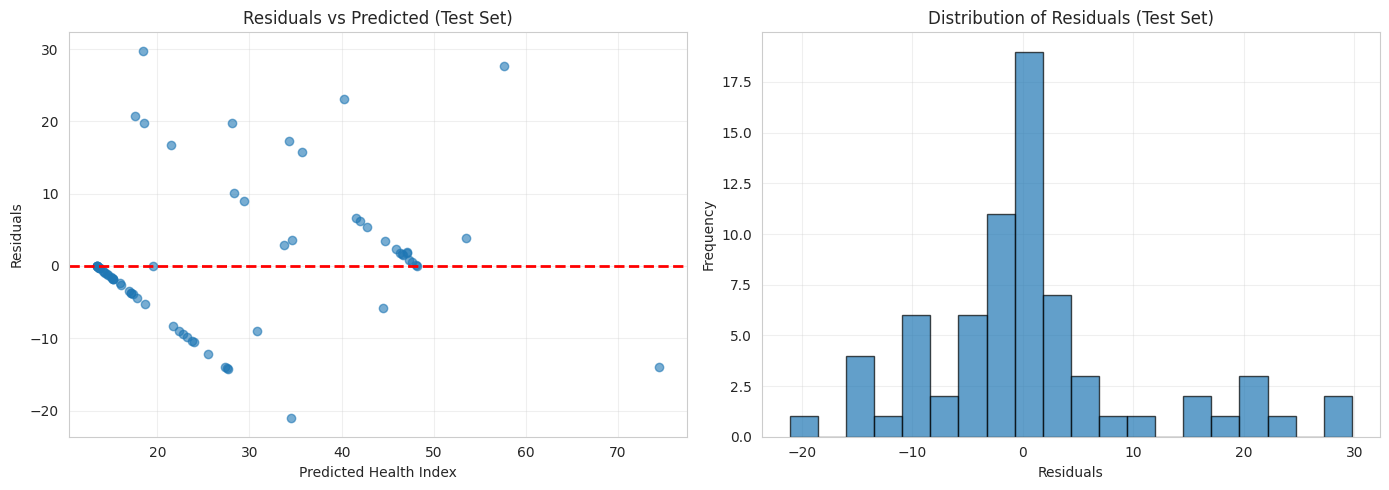


Residuals (Test Set):
  Mean:    0.6886
  Std Dev: 9.7514


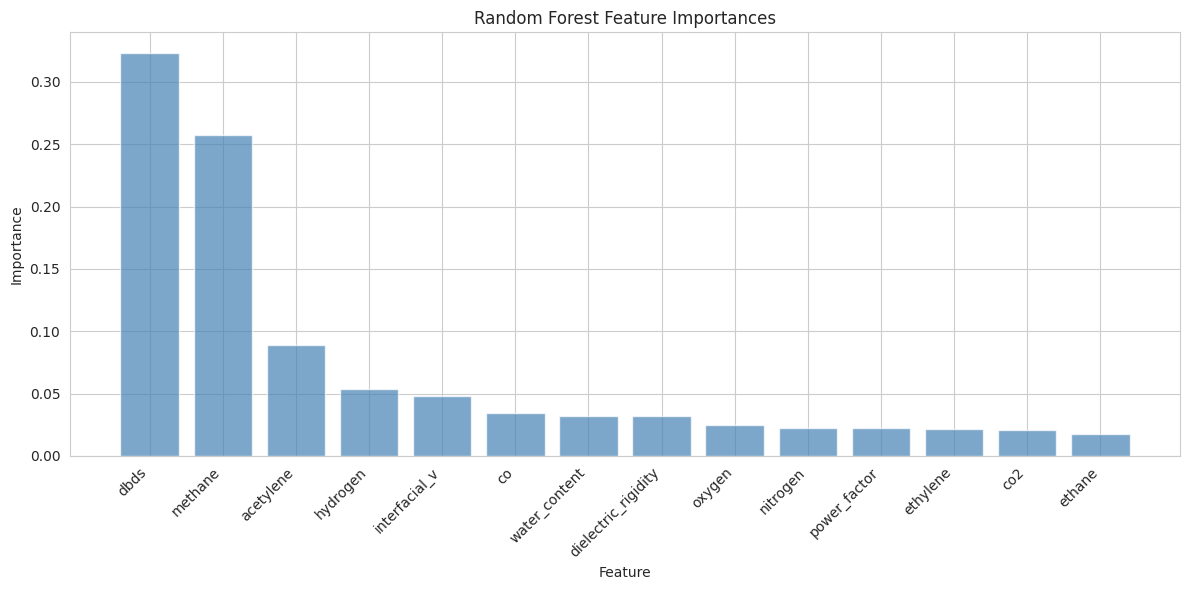


Feature Importances (ranked):
  dbds                      0.3235
  methane                   0.2575
  acetylene                 0.0887
  hydrogen                  0.0539
  interfacial_v             0.0483
  co                        0.0344
  water_content             0.0318
  dielectric_rigidity       0.0317
  oxygen                    0.0248
  nitrogen                  0.0225
  power_factor              0.0225
  ethylene                  0.0216
  co2                       0.0211
  ethane                    0.0176


In [14]:
# Plot 1: Predicted vs Actual
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, actual, pred, title, color in zip(
    axes,
    [y_train, y_val, y_test],
    [y_train_pred, y_val_pred, y_test_pred],
    ['Training', 'Validation', 'Test'],
    ['steelblue', 'orange', 'green']
):
    r2 = r2_score(actual, pred)
    ax.scatter(actual, pred, alpha=0.6, s=30, color=color)
    mn = min(actual.min(), pred.min())
    mx = max(actual.max(), pred.max())
    ax.plot([mn, mx], [mn, mx], 'r--', lw=2)
    ax.set_xlabel('Actual Health Index')
    ax.set_ylabel('Predicted Health Index')
    ax.set_title(f'{title} Set (R² = {r2:.4f})')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('predicted_vs_actual.png', dpi=150)
plt.show()

# Plot 2: Residuals
residuals = y_test.values - y_test_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test_pred, residuals, alpha=0.6)
axes[0].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0].set_xlabel('Predicted Health Index')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Predicted (Test Set)')
axes[0].grid(True, alpha=0.3)

axes[1].hist(residuals, bins=20, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Residuals')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Residuals (Test Set)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('residuals.png', dpi=150)
plt.show()

print(f"\nResiduals (Test Set):")
print(f"  Mean:    {residuals.mean():.4f}")
print(f"  Std Dev: {residuals.std():.4f}")

# Plot 3: Feature Importance
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 6))
plt.bar(range(len(FEATURE_COLUMNS)),
        importances[indices], align='center', alpha=0.7, color='steelblue')
plt.xticks(range(len(FEATURE_COLUMNS)),
           [FEATURE_COLUMNS[i] for i in indices], rotation=45, ha='right')
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.title('Random Forest Feature Importances')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

print("\nFeature Importances (ranked):")
for i in indices:
    print(f"  {FEATURE_COLUMNS[i]:<25} {importances[i]:.4f}")

In [15]:
os.makedirs('artifacts', exist_ok=True)

MODEL_PATH  = 'artifacts/health_index_model.pkl'
SCALER_PATH = 'artifacts/health_index_scalers.pkl'

# Save model
with open(MODEL_PATH, 'wb') as f:
    pickle.dump(model, f)
print(f"\nModel saved to: {MODEL_PATH}")

# Save scaler — only scaler_X needed since RF predicts in original y scale
with open(SCALER_PATH, 'wb') as f:
    pickle.dump({'scaler_X': scaler_X}, f)
print(f"Scaler saved to: {SCALER_PATH}")

print(f"\nModel size:  {os.path.getsize(MODEL_PATH)  / 1024:.1f} KB")
print(f"Scaler size: {os.path.getsize(SCALER_PATH) / 1024:.1f} KB")


Model saved to: artifacts/health_index_model.pkl
Scaler saved to: artifacts/health_index_scalers.pkl

Model size:  3323.1 KB
Scaler size: 1.0 KB
